# Iris Flower Classification

**Name:** Zoya Chaudhary

**Track:** Data Science, Oasis Infobyte SIP

**Task:** Task 1 — Iris Flower Classification

Training and comparing multiple machine learning classifiers to predict iris flower species from their physical measurements.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

sns.set_style("whitegrid")
print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)

df["species_code"] = iris.target
df["species"] = df["species_code"].map(dict(enumerate(iris.target_names)))
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_code,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## 1. Exploratory Data Analysis (EDA)

Before modelling, let's understand the shape, types, and quality of our data.

In [3]:
print("Shape of the dataset:", df.shape)
print()
print("Data types:")
print(df.dtypes)
print()
print("Missing values per column:")
print(df.isnull().sum())

Shape of the dataset: (150, 6)

Data types:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species_code           int64
species               object
dtype: object

Missing values per column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species_code         0
species              0
dtype: int64


In [4]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_code
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [5]:
df["species"].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

**Observation:** The dataset is small (150 rows, 4 numeric features), has no missing values,
and is perfectly balanced across the three species (50 samples each) — so accuracy will be a
fair evaluation metric later, with no need for class-imbalance handling.

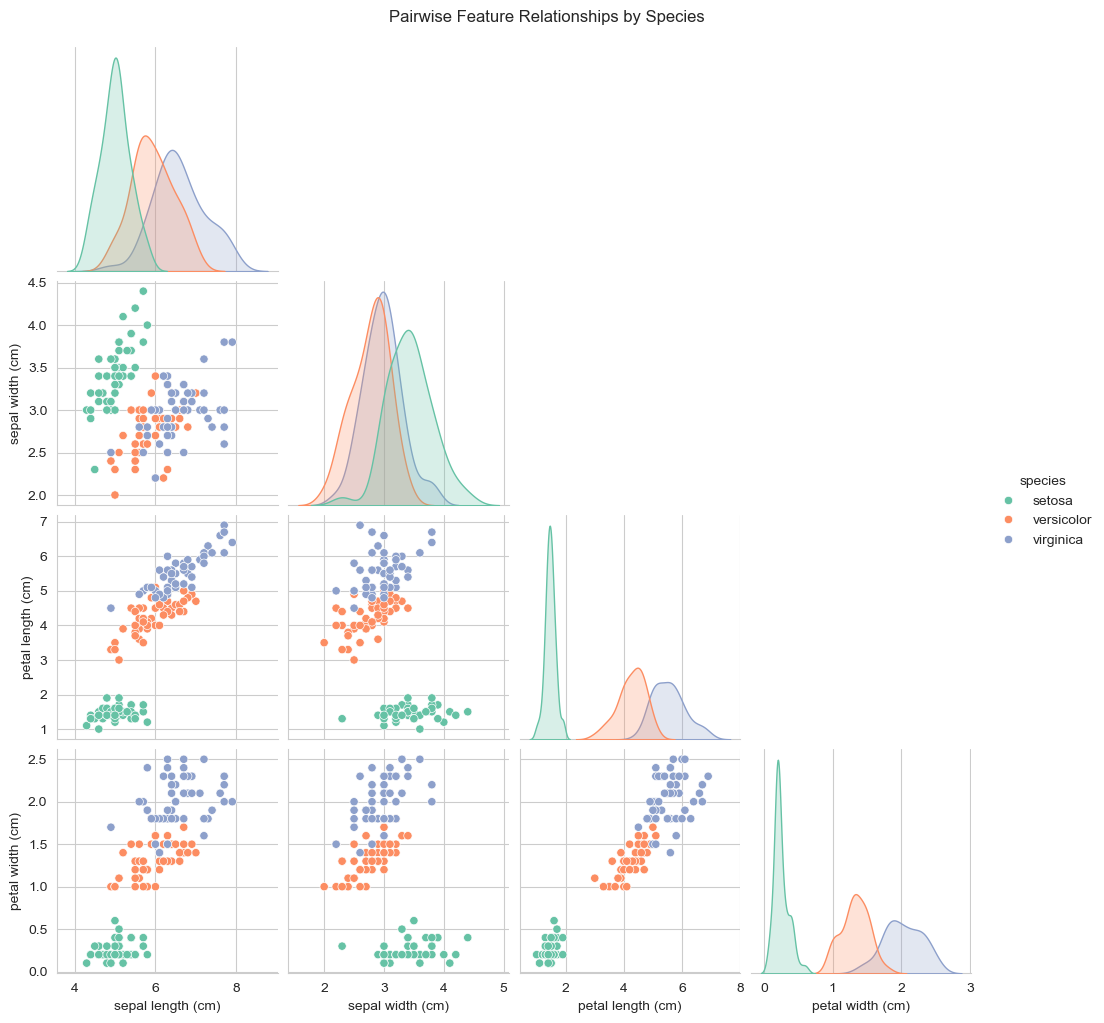

In [6]:
sns.pairplot(df, hue="species", vars=iris.feature_names, palette="Set2", corner=True)
plt.suptitle("Pairwise Feature Relationships by Species", y=1.02)
plt.show()

**Observation:** *Petal length* and *petal width* separate the three species very cleanly —
*Setosa* forms a tight, fully isolated cluster on almost every feature pair, while *Versicolor*
and *Virginica* show some overlap, mostly on sepal measurements. Sepal width alone shows almost
no separation between species.

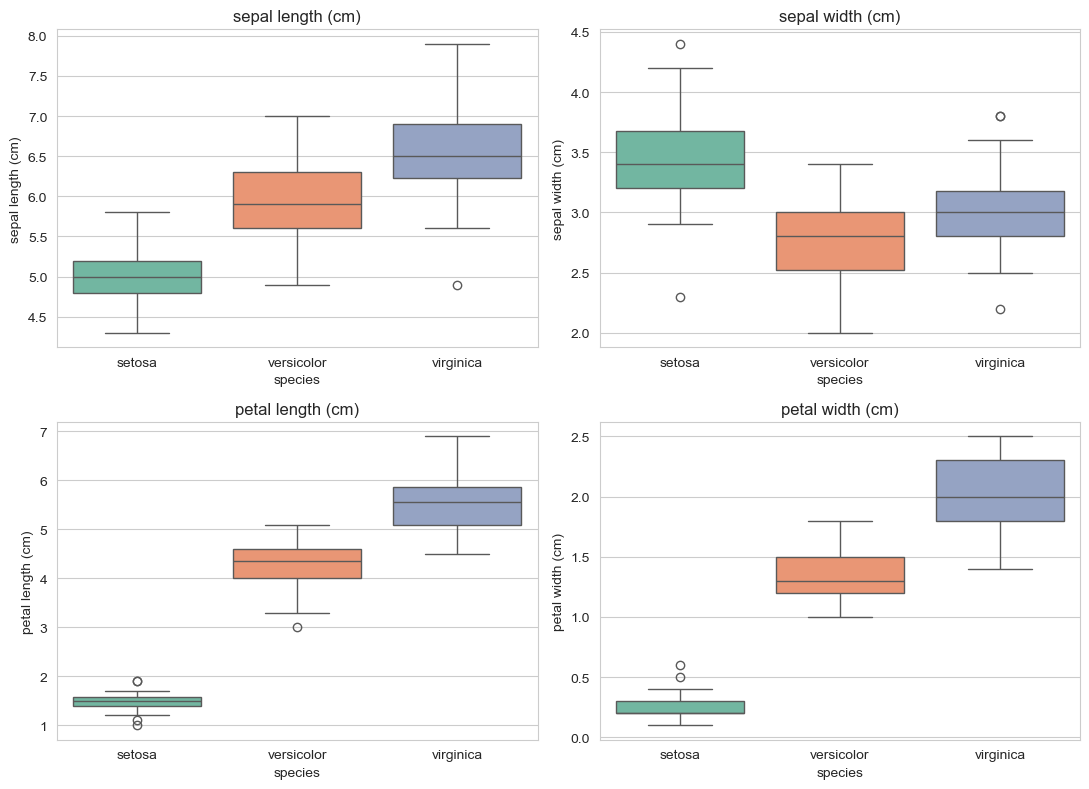

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.flatten()

for ax, feature in zip(axes, iris.feature_names):
    sns.boxplot(data=df, x="species", y=feature, hue="species", palette="Set2", ax=ax, legend=False)
    ax.set_title(feature)

plt.tight_layout()
plt.show()

Petal length and petal width are clearly the stars here, setosa's box doesn't even come close
to touching the other two species on either measurement. Versicolor and virginica overlap more,
but even then petal length separates them better than anything sepal-related does. Sepal width
is honestly not doing much work and all three species' boxes are basically stacked on top of each
other.

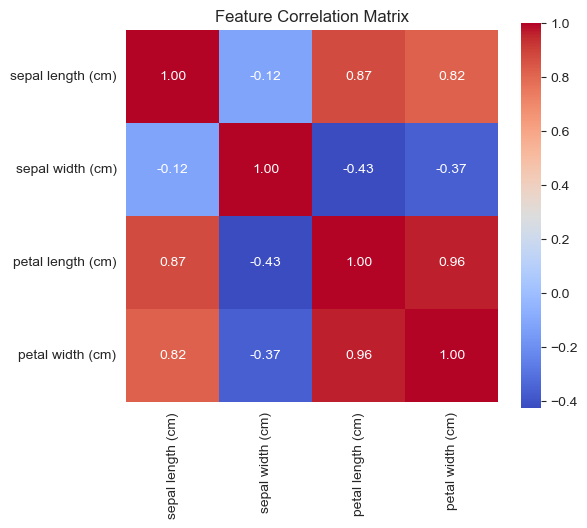

In [8]:
plt.figure(figsize=(6, 5))
corr = df[iris.feature_names].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Feature Correlation Matrix")
plt.show()

Petal length and petal width are almost perfectly correlated (0.96) makes sense, bigger
petals tend to be both longer and wider. Sepal width is the odd one out, weakly (and
negatively) correlated with everything else, which tracks with it being the least useful
feature for telling species apart.

## Feature Selection

Petal length and petal width are clearly the most useful features for telling the species
apart. The pairplot and box plots both show setosa sitting completely on its own, and
versicolor/virginica separating reasonably well too, especially on petal length. Sepal length
is somewhat useful but noisier. Sepal width barely helps at all, its distributions overlap
heavily across all three species.

That said, since petal length and petal width are so highly correlated (0.96), they're
carrying a lot of the same information so using both isn't really "double" the signal.

For this notebook, I'm still going to train the models on all four features rather than
dropping sepal width. The dataset is tiny and clean, so there's no real computational cost to
keeping it, and tree-based models especially can just ignore weak features on their own.

## 2. Train/Test Split

We'll split the data 80/20, using stratification so each species is proportionally
represented in both the training and test sets.

In [9]:
from sklearn.model_selection import train_test_split

X = df[iris.feature_names]

y = df["species_code"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


**Feature scaling:** Logistic Regression and KNN are distance/gradient-based and benefit from
standardised features. Tree-based models are scale-invariant, so this step doesn't help or hurt
them — scaling once and reusing it everywhere keeps things simple.

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaling complete.")
print(X_train_scaled[:3]) 

Scaling complete.
[[-1.72156775 -0.33210111 -1.34572231 -1.32327558]
 [-1.12449223 -1.22765467  0.41450518  0.6517626 ]
 [ 1.14439475 -0.5559895   0.58484978  0.25675496]]


## 3. Train Multiple Classifiers

Training four classifiers to compare: Logistic Regression, K-Nearest Neighbours, Decision
Tree, and Random Forest.

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=200, random_state=42),
    "K-Nearest Neighbours": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)         
    y_pred = model.predict(X_test_scaled)         
    acc = accuracy_score(y_test, y_pred)           

    results[name] = {"model": model, "y_pred": y_pred, "accuracy": acc}
    print(f"{name:22s} -> Accuracy: {acc:.4f}")

Logistic Regression    -> Accuracy: 0.9333
K-Nearest Neighbours   -> Accuracy: 0.9333
Decision Tree          -> Accuracy: 0.9333
Random Forest          -> Accuracy: 0.9000


 ## 4. Model Evaluation

Accuracy alone doesn't tell the full story, let's look at confusion matrices and
classification reports to see exactly where each model is getting confused.

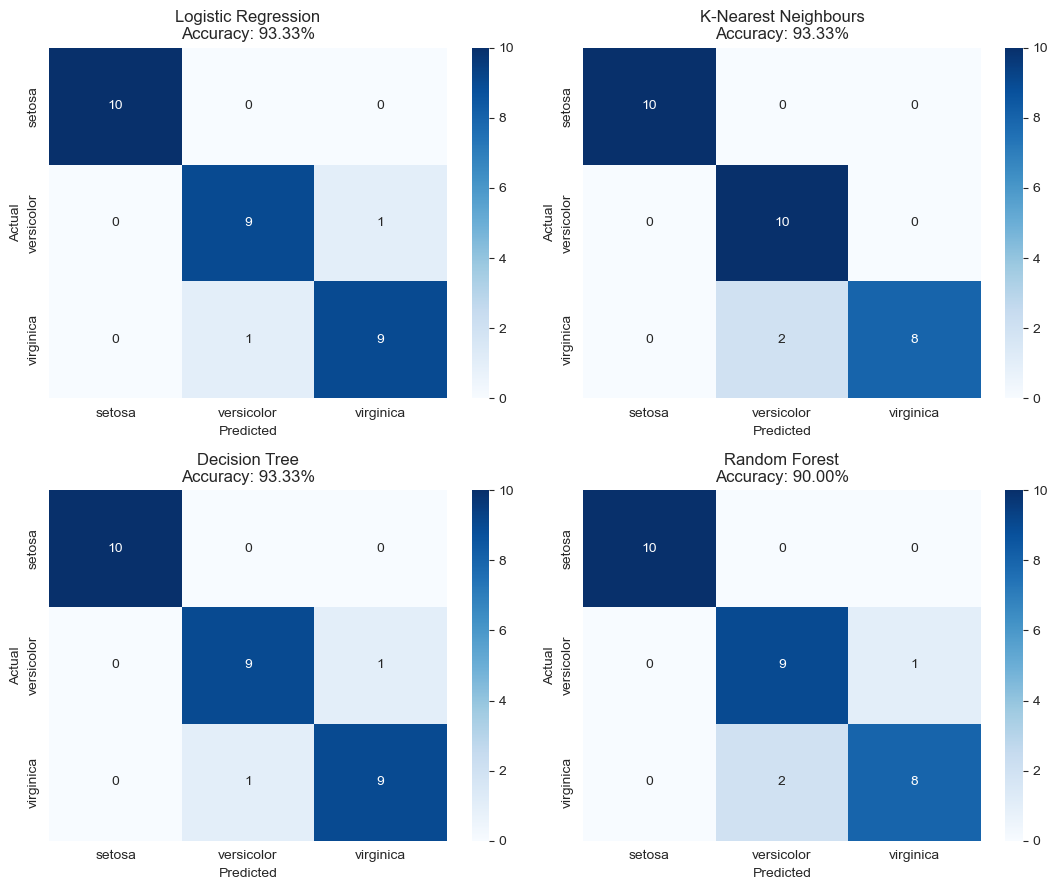

In [12]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=iris.target_names, yticklabels=iris.target_names, ax=ax)
    ax.set_title(f"{name}\nAccuracy: {res['accuracy']:.2%}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

Interesting pattern here — every single model got all 10 setosa flowers correct, zero
mistakes. All the errors are versicolor and virginica getting confused with each other,
which makes total sense given what the pairplot showed earlier. Those two species overlap
a bit on petal measurements, while setosa is totally separate.

In [13]:
from sklearn.metrics import classification_report

for name, res in results.items():
    print(f"===== {name} =====")
    print(classification_report(y_test, res["y_pred"], target_names=iris.target_names))

===== Logistic Regression =====
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

===== K-Nearest Neighbours =====
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30

===== Decision Tree =====
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90     

Setosa is perfect across every single model - 1.00 precision and recall, no exceptions. The
real differences between models show up in versicolor vs virginica. KNN is a good example:
it catches every real versicolor (recall 1.00) but that comes at a cost some virginica
flowers get mislabeled as versicolor too, which is why virginica's recall drops to 0.80.

## 5. Best Model Selection

In [14]:
summary = pd.DataFrame({
    "Model": list(results.keys()),
    "Accuracy": [res["accuracy"] for res in results.values()],
}).sort_values("Accuracy", ascending=False).reset_index(drop=True)

summary

,Model,Accuracy
0,Logistic Regression,0.933333
1,K-Nearest Neighbours,0.933333
2,Decision Tree,0.933333
3,Random Forest,0.900000


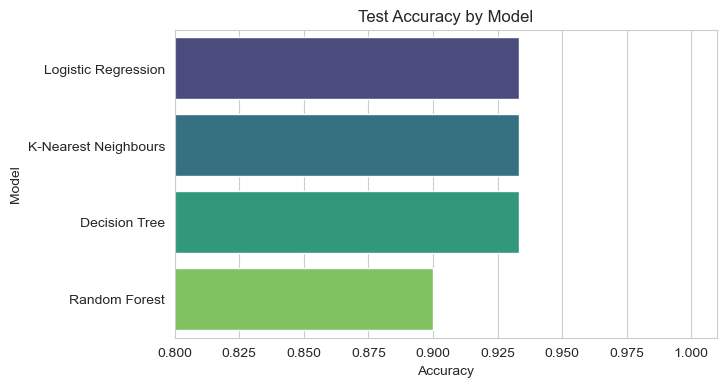

Best performing model: Logistic Regression (Accuracy: 93.33%)


In [15]:
plt.figure(figsize=(7, 4))
sns.barplot(data=summary, x="Accuracy", y="Model", hue="Model", palette="viridis", legend=False)
plt.xlim(0.8, 1.01)
plt.title("Test Accuracy by Model")
plt.show()

best_model_name = summary.iloc[0]["Model"]
best_accuracy = summary.iloc[0]["Accuracy"]
print(f"Best performing model: {best_model_name} (Accuracy: {best_accuracy:.2%})")

## Conclusion

Three models — Logistic Regression, KNN, and Decision Tree, all tied at 93.3% accuracy, with
Random Forest slightly behind at 90%. Honestly, with a test set of only 30 flowers, a single
misclassification swings the accuracy by over 3%, so I wouldn't read too much into these small
differences with a dataset this small, cross-validation would give a more reliable picture
than one single train/test split.

That said, if I had to pick one model to actually use, I'd go with Logistic Regression. It's
the simplest of the four, trains almost instantly, and its coefficients are easy to interpret
useful if someone later asks "why did the model predict virginica here?" Random Forest is
usually the stronger choice on messier, larger datasets, but here it's arguably overkill: 200
trees to classify 150 flowers with 4 clean features is a lot of firepower for a fairly simple
problem.

Every model, without exception, correctly classified 100% of the setosa flowers, confirming
what the very first pairplot showed us. All the disagreement between models happened on
versicolor vs virginica, which have some real overlap in petal measurements.